# 04 — Swin Transformer Training

**Brain Tumor Detection** — Model 3 of 3.

Two-stage training of `swin_tiny_patch4_window7_224` (28 M params,
ImageNet-1K pretrained):

1. **Stage 1 (warmup)** — freeze backbone, train head for 3 epochs at LR=1e-3.
2. **Stage 2 (fine-tune)** — unfreeze, fine-tune for 6 epochs at LR=2e-5
   (deliberately 50× smaller than stage 1 to preserve attention weights).

Outputs:
* `models/swin_model.pth`
* `outputs/reports/swin_stage{1,2}_history.json`
* `outputs/plots/swin_training_curves.png`
* `outputs/confusion_matrices/swin_val_cm.png`
* `outputs/reports/model_comparison.csv` (CNN vs EffNet vs Swin)

In [1]:
# --- 0. Setup ---------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / '__init__.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.config import (
    CLASS_NAMES, NUM_CLASSES, BATCH_SIZE, NUM_WORKERS,
    OUTPUTS_DIR, MODELS_DIR, LOGS_DIR,
)
from src.data_loader import get_dataloaders
from src.swin_model   import build_swin_model
from src.train        import fit, evaluate
from src.evaluate     import (
    logits_to_preds, build_classification_report,
    plot_confusion_matrix, per_class_metrics_df,
)
from src.utils        import get_device, set_seed

set_seed(42)
device = get_device()
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce GTX 1650


## 1. DataLoaders

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)
print(f'Train batches: {len(train_loader)}  ({len(train_loader.dataset)} images)')
print(f'Val   batches: {len(val_loader)}    ({len(val_loader.dataset)} images)')

Train batches: 140  (4480 images)
Val   batches: 35    (1120 images)


## 2. Build the model (Stage 1: frozen backbone)

In [3]:
model = build_swin_model(
    model_name      = 'swin_tiny_patch4_window7_224',
    num_classes     = NUM_CLASSES,
    pretrained      = True,
    freeze_backbone = True,
    dropout         = 0.3,
)
print(f'Model           : {model.model_name}')
print(f'Feature dim     : {model.feature_dim}')
print(f'Total params    : {model.num_total_parameters():,}')
print(f'Stage 1 trainable: {model.num_trainable_parameters():,}  (head only)')

Model           : swin_tiny_patch4_window7_224
Feature dim     : 768
Total params    : 27,522,430
Stage 1 trainable: 3,076  (head only)


## 3. Stage 1 — Warmup

3 epochs at LR=1e-3. Backbone frozen → only 3,076 head params learn.

In [4]:
model, history_s1, best_acc_s1 = fit(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 3,
    lr            = 1e-3,
    weight_decay  = 1e-4,
    patience      = 10,
    use_amp       = (device.type == 'cuda'),
    amp_dtype     = torch.bfloat16,
    run_name      = 'swin_stage1',
    checkpoint_path = MODELS_DIR / 'swin_model.pth',
    log_dir         = LOGS_DIR    / 'swin_stage1',
    history_path    = OUTPUTS_DIR / 'reports' / 'swin_stage1_history.json',
    seed          = 42,
)

[fit] run_name        = swin_stage1


[fit] device          = cuda
[fit] trainable params = 3,076
[fit] train batches    = 140 | val batches = 35
[fit] lr=1e-03  wd=1e-04  amp=True(torch.bfloat16)  epochs=3  patience=10
[fit] checkpoint -> C:\Brain Tumor Detection\models\swin_model.pth
[fit] tensorboard -> C:\Brain Tumor Detection\logs\swin_stage1



E01/3 train:   0%|          | 0/140 [00:14<?, ?it/s]

E01/3 val:   0%|          | 0/35 [00:19<?, ?it/s]

Epoch 01/3  train_loss=0.7501 train_acc=0.7022  |  val_loss=0.5465 val_acc=0.7804  lr=7.53e-04  time=82.6s  <- best


...

E02/3 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 02/3  train_loss=0.4873 train_acc=0.8154  |  val_loss=0.4398 val_acc=0.8491  lr=2.58e-04  time=50.3s  <- best


E03/3 train:   0%|          | 0/140 [00:00<?, ?it/s]

E03/3 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 03/3  train_loss=0.4442 train_acc=0.8371  |  val_loss=0.4239 val_acc=0.8509  lr=1.00e-05  time=52.5s  <- best

[fit] Done in 3.1 min
[fit] Best val_acc = 0.8509 (epoch 3)
[fit] Best val_loss= 0.4239
[fit] Checkpoint saved -> C:\Brain Tumor Detection\models\swin_model.pth
[fit] History saved    -> C:\Brain Tumor Detection\outputs\reports\swin_stage1_history.json


## 4. Unfreeze for Stage 2

In [5]:
model.unfreeze_backbone()
print(f'Stage 2 trainable: {model.num_trainable_parameters():,}  (entire model)')

Stage 2 trainable: 27,522,430  (entire model)


## 5. Stage 2 — Fine-tune the whole Swin

6 epochs at LR=2e-5 — **50× smaller than stage 1** because transformer
attention weights are extremely sensitive to large gradient updates.

In [ ]:
model, history_s2, best_acc_s2 = fit(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 4,           # tuned for ~10-min total runtime on GTX 1650
    lr            = 2e-5,        # critical: very small LR for transformer fine-tune
    weight_decay  = 1e-4,
    patience      = 4,
    use_amp       = (device.type == 'cuda'),
    amp_dtype     = torch.bfloat16,
    run_name      = 'swin_stage2',
    checkpoint_path = MODELS_DIR / 'swin_model.pth',
    log_dir         = LOGS_DIR    / 'swin_stage2',
    history_path    = OUTPUTS_DIR / 'reports' / 'swin_stage2_history.json',
    seed          = 42,
)

best_val_acc = max(best_acc_s1, best_acc_s2)
print(f'\nBest val_acc (Stage 1) : {best_acc_s1:.4f}')
print(f'Best val_acc (Stage 2) : {best_acc_s2:.4f}')
print(f'Overall best val_acc   : {best_val_acc:.4f}')

[fit] run_name        = swin_stage2
[fit] device          = cuda
[fit] trainable params = 27,522,430
[fit] train batches    = 140 | val batches = 35
[fit] lr=2e-05  wd=1e-04  amp=True(torch.bfloat16)  epochs=4  patience=4
[fit] checkpoint -> C:\Brain Tumor Detection\models\swin_model.pth
[fit] tensorboard -> C:\Brain Tumor Detection\logs\swin_stage2



E01/4 train:   0%|          | 0/140 [00:00<?, ?it/s]

E01/4 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 01/4  train_loss=0.3366 train_acc=0.8734  |  val_loss=0.1811 val_acc=0.9321  lr=1.71e-05  time=137.6s  <- best


E02/4 train:   0%|          | 0/140 [00:00<?, ?it/s]

...

E03/4 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 03/4  train_loss=0.1342 train_acc=0.9500  |  val_loss=0.0915 val_acc=0.9634  lr=3.10e-06  time=140.6s  <- best


E04/4 train:   0%|          | 0/140 [00:00<?, ?it/s]

E04/4 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 04/4  train_loss=0.1070 train_acc=0.9583  |  val_loss=0.0921 val_acc=0.9670  lr=2.00e-07  time=145.7s  <- best

[fit] Done in 9.4 min
[fit] Best val_acc = 0.9670 (epoch 4)
[fit] Best val_loss= 0.0921
[fit] Checkpoint saved -> C:\Brain Tumor Detection\models\swin_model.pth
[fit] History saved    -> C:\Brain Tumor Detection\outputs\reports\swin_stage2_history.json

Best val_acc (Stage 1) : 0.8509
Best val_acc (Stage 2) : 0.9670
Overall best val_acc   : 0.9670


## 6. Combined training curves

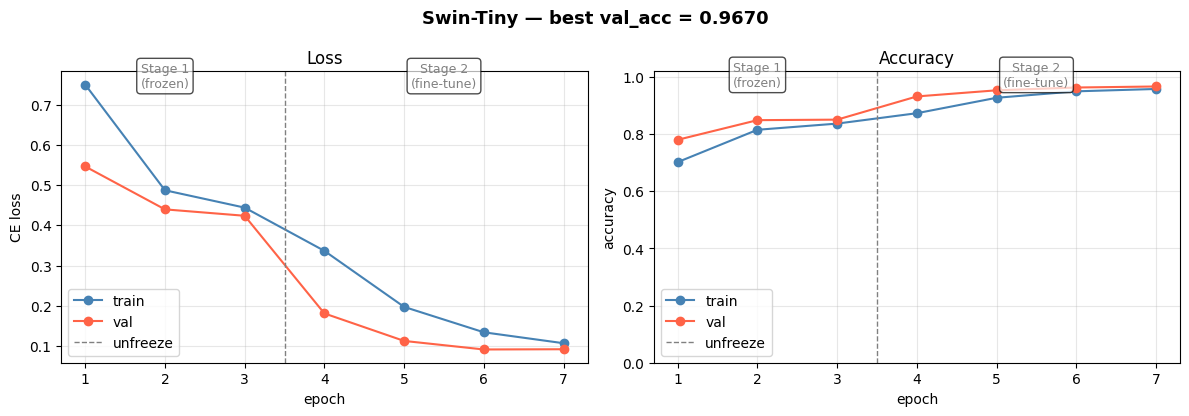

In [7]:
n1 = len(history_s1.train_loss)
n2 = len(history_s2.train_loss)
epochs = np.arange(1, n1 + n2 + 1)

train_loss = history_s1.train_loss + history_s2.train_loss
val_loss   = history_s1.val_loss   + history_s2.val_loss
train_acc  = history_s1.train_acc  + history_s2.train_acc
val_acc    = history_s1.val_acc    + history_s2.val_acc

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(epochs, train_loss, '-o', label='train', color='steelblue')
axes[0].plot(epochs, val_loss,   '-o', label='val',   color='tomato')
axes[0].axvline(n1 + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
axes[0].set_title('Loss');     axes[0].set_xlabel('epoch'); axes[0].set_ylabel('CE loss')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, train_acc, '-o', label='train', color='steelblue')
axes[1].plot(epochs, val_acc,   '-o', label='val',   color='tomato')
axes[1].axvline(n1 + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.02); axes[1].grid(alpha=0.3); axes[1].legend()

for ax in axes:
    ax.text(n1 / 2 + 0.5, ax.get_ylim()[1] * 0.95, 'Stage 1\n(frozen)',
            ha='center', fontsize=9, color='gray',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.text(n1 + n2 / 2 + 0.5, ax.get_ylim()[1] * 0.95, 'Stage 2\n(fine-tune)',
            ha='center', fontsize=9, color='gray',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

fig.suptitle(
    f'Swin-Tiny — best val_acc = {best_val_acc:.4f}',
    fontsize=13, fontweight='bold',
)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'plots' / 'swin_training_curves.png',
            dpi=120, bbox_inches='tight')
plt.show()

## 7. Validation evaluation — confusion matrix

final val:   0%|          | 0/35 [00:00<?, ?it/s]

Final val loss: 0.0921
Final val acc : 0.9670


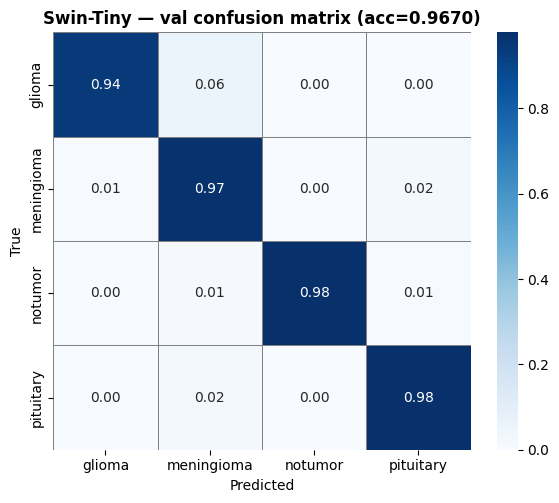

In [8]:
val_loss, val_acc, val_logits, val_labels = evaluate(
    model, val_loader, nn.CrossEntropyLoss(), device,
    use_amp=(device.type == 'cuda'),
    amp_dtype=torch.bfloat16,
    desc='final val',
    return_predictions=True,
)
y_pred = logits_to_preds(val_logits)
y_true = val_labels.numpy()
print(f'Final val loss: {val_loss:.4f}')
print(f'Final val acc : {val_acc:.4f}')

fig = plot_confusion_matrix(
    y_true, y_pred, CLASS_NAMES, normalize=True,
    title=f'Swin-Tiny — val confusion matrix (acc={val_acc:.4f})',
    save_path=OUTPUTS_DIR / 'confusion_matrices' / 'swin_val_cm.png',
)
plt.show()

## 8. Classification report

In [9]:
text, _ = build_classification_report(y_true, y_pred, CLASS_NAMES)
print(text)

df = per_class_metrics_df(y_true, y_pred, CLASS_NAMES)
for c in ['precision', 'recall', 'f1']:
    df[c] = df[c].round(4)
print(df.to_string(index=False))

              precision    recall  f1-score   support

      glioma     0.9925    0.9429    0.9670       280
  meningioma     0.9125    0.9679    0.9393       280
     notumor     0.9964    0.9786    0.9874       280
   pituitary     0.9716    0.9786    0.9751       280

    accuracy                         0.9670      1120
   macro avg     0.9682    0.9670    0.9672      1120
weighted avg     0.9682    0.9670    0.9672      1120

     class  precision  recall     f1  support
    glioma     0.9925  0.9429 0.9670      280
meningioma     0.9125  0.9679 0.9393      280
   notumor     0.9964  0.9786 0.9874      280
 pituitary     0.9716  0.9786 0.9751      280


## 9. Three-way model comparison

In [10]:
import json, pandas as pd

cnn_hist = json.loads((OUTPUTS_DIR / 'reports' / 'cnn_history.json').read_text())
tl_s1    = json.loads((OUTPUTS_DIR / 'reports' / 'transfer_stage1_history.json').read_text())
tl_s2    = json.loads((OUTPUTS_DIR / 'reports' / 'transfer_stage2_history.json').read_text())

cnn_best = max(cnn_hist['val_acc'])
tl_best  = max(max(tl_s1['val_acc']), max(tl_s2['val_acc']))

comparison = pd.DataFrame({
    'Model':         ['Custom CNN', 'EfficientNet-B0', 'Swin-Tiny'],
    'Total params':  [1_206_628, 4_012_672, model.num_total_parameters()],
    'Init':          ['random (Kaiming)', 'ImageNet pretrained', 'ImageNet pretrained'],
    'Core op':       ['3x3 conv', 'depthwise-sep + SE', 'window self-attention'],
    'Best val_acc':  [round(cnn_best, 4), round(tl_best, 4), round(best_val_acc, 4)],
})
print(comparison.to_string(index=False))

OUTPUTS_DIR.joinpath('reports').mkdir(parents=True, exist_ok=True)
comparison.to_csv(OUTPUTS_DIR / 'reports' / 'model_comparison.csv', index=False)
print(f"\nSaved to: {OUTPUTS_DIR / 'reports' / 'model_comparison.csv'}")

          Model  Total params                Init               Core op  Best val_acc
     Custom CNN       1206628    random (Kaiming)              3x3 conv        0.9036
EfficientNet-B0       4012672 ImageNet pretrained    depthwise-sep + SE        0.9893
      Swin-Tiny      27522430 ImageNet pretrained window self-attention        0.9670

Saved to: C:\Brain Tumor Detection\outputs\reports\model_comparison.csv


## 10. Summary

All three individual models are now trained:

* `models/cnn_model.pth`
* `models/transfer_model.pth`
* `models/swin_model.pth`

**Next:** STEP 14 — build the ensemble (soft voting + weighted averaging)
and see if combining the three can push accuracy higher than any one alone.